<a href="https://colab.research.google.com/github/cgm2179/Branch_2_Diffusion_Transformer_efficiency_for_small_model/blob/main/Section%208%20-%20Cameron's%20Version/regime%201/04_compare_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# regime 1 / Compare Results — all rules, equal wall-clock
Loads `results/{backprop,two_factor,three_factor,three_factor_v2}.json` from Drive and compares them (missing ones are skipped). Includes a dedicated three-factor **v1 vs v2** head-to-head.

## 1. Setup

In [1]:
import os, json, math, torch
import torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
device = 'cuda' if torch.cuda.is_available() else 'cpu'
USE_DRIVE, DRIVE_SUBDIR = True, 'Section8_regime1'
if USE_DRIVE:
    try:
        from google.colab import drive; drive.mount('/content/drive')
        STORE = os.path.join('/content/drive/MyDrive', DRIVE_SUBDIR)
    except Exception as e:
        print('Drive mount failed:', e); STORE = os.path.join('/content', DRIVE_SUBDIR)
else:
    STORE = os.path.join('.', DRIVE_SUBDIR)
RESULTS_DIR = os.path.join(STORE, 'results'); CKPT_DIR = os.path.join(STORE, 'checkpoints')
EXTRA_RESULTS_DIRS = []   # merge results JSONs from other Google accounts here (see the "merge" cell below)
EXTRA_CKPT_DIRS    = []   # extra checkpoint folders for the predictions cell (same idea)
METHODS = ['backprop', 'two_factor', 'three_factor', 'three_factor_v2', 'three_factor_v3', 'backprop_100M']
LABELS  = {'backprop':'Backpropagation', 'two_factor':'Two-factor Hebbian',
           'three_factor':'Three-factor v1 (cos~0.5)', 'three_factor_v2':'Three-factor v2 (cos~0.09)',
           'three_factor_v3':'Three-factor v3 (cos~0.01)', 'backprop_100M':'Backprop 100M (ceiling)'}
COLORS  = {'backprop':'#1F3864', 'two_factor':'#B8860B', 'three_factor':'#C62828',
           'three_factor_v2':'#E67E22', 'three_factor_v3':'#7B1FA2', 'backprop_100M':'#2E7D32'}
print('reading', RESULTS_DIR)

Mounted at /content/drive
reading /content/drive/MyDrive/Section8_regime1/results


## 1b. Merge results from another account (optional)

In [2]:
# --- OPTIONAL: merge results/checkpoints exported from ANOTHER Google account ---
# If some methods ran on a different account (their JSONs live on a different Drive), either set
# EXTRA_RESULTS_DIRS above to a Drive folder you can see, OR run this cell and upload the JSON files
# (e.g. three_factor_v3.json). They get merged into the comparison below. Skip if everything's on this Drive.
import os
try:
    from google.colab import files
    up = files.upload()                                  # pick <method>.json (and optionally <method>.pt)
    import shutil
    for fn in up:
        dst = '/content/extra_results' if fn.endswith('.json') else '/content/extra_ckpts'
        os.makedirs(dst, exist_ok=True); shutil.move(fn, os.path.join(dst, fn))
    if os.path.isdir('/content/extra_results') and '/content/extra_results' not in EXTRA_RESULTS_DIRS:
        EXTRA_RESULTS_DIRS.append('/content/extra_results')
    if os.path.isdir('/content/extra_ckpts') and '/content/extra_ckpts' not in EXTRA_CKPT_DIRS:
        EXTRA_CKPT_DIRS.append('/content/extra_ckpts')
    print('EXTRA_RESULTS_DIRS =', EXTRA_RESULTS_DIRS)
except Exception as e:
    print('nothing uploaded (fine if all results are already on this Drive):', e)

EXTRA_RESULTS_DIRS = []


## 2. Load Results

In [3]:
def _find(m, dirs):
    for d in dirs:
        p = os.path.join(d, f'{m}.json')
        if os.path.exists(p): return p
    return None
R = {}; _loaded = []; _missing = []
for m in METHODS:
    p = _find(m, [RESULTS_DIR] + EXTRA_RESULTS_DIRS)
    if p:
        R[m] = json.load(open(p)); _loaded.append(m)
        md, s = R[m]['meta'], R[m]['summary']
        where = '' if os.path.dirname(p) == RESULTS_DIR else f'  <- {os.path.dirname(p)}'
        print(f'loaded  {m:16} {md["total_steps"]:>8,} steps  {md["wall_clock_sec"]/3600:5.2f}h  '
              f'final acc {s["final_acc"]:.3f}  best loss {s["best_loss"]:.4f}{where}')
    else:
        _missing.append(m); print(f'MISSING {m:16} (searched {[RESULTS_DIR] + EXTRA_RESULTS_DIRS})')
print(f'\n=== {len(_loaded)}/{len(METHODS)} loaded: {_loaded}  |  missing: {_missing} ===')

loaded  backprop          692,954 steps   2.00h  final acc 0.986  best loss 0.0679
loaded  two_factor        874,811 steps   2.00h  final acc 0.098  best loss 2.4146
loaded  three_factor           33 steps   2.03h  final acc 0.493  best loss 1.4567
loaded  three_factor_v2     1,367 steps   2.00h  final acc 0.880  best loss 0.3905
loaded  three_factor_v3    87,664 steps   2.00h  final acc 0.941  best loss 0.1856
loaded  backprop_100M     115,417 steps   2.00h  final acc 0.919  best loss 0.2441

=== 6/6 loaded: ['backprop', 'two_factor', 'three_factor', 'three_factor_v2', 'three_factor_v3', 'backprop_100M']  |  missing: [] ===


## 3. Configuration

In [4]:
for m in R:
    md = R[m]['meta']
    print('='*64); print(LABELS[m])
    print(f'  P={md["P"]:,}  seed={md["seed"]}  device={md["device"]}  epochs={md["epochs"]:.3f}')
    print('  config:', json.dumps(md['config']))

Backpropagation
  P=1,013,066  seed=0  device=cuda  epochs=739.151
  config: {"METHOD": "backprop", "SEED": 0, "PATCH": 7, "EMBED_DIM": 176, "DEPTH": 4, "HEADS": 8, "MLP_RATIO": 2, "BATCH": 64, "TIME_BUDGET_HOURS": 2.0, "LR_BP": 0.0003}
Two-factor Hebbian
  P=1,013,066  seed=0  device=cuda  epochs=933.132
  config: {"METHOD": "two_factor", "SEED": 0, "PATCH": 7, "EMBED_DIM": 176, "DEPTH": 4, "HEADS": 8, "MLP_RATIO": 2, "BATCH": 64, "TIME_BUDGET_HOURS": 2.0, "ETA_HEBB": 0.001, "OJA_DECAY": 1.0}
Three-factor v1 (cos~0.5)
  P=1,013,066  seed=0  device=cuda  epochs=0.035
  config: {"METHOD": "three_factor", "SEED": 0, "PATCH": 7, "EMBED_DIM": 176, "DEPTH": 4, "HEADS": 8, "MLP_RATIO": 2, "BATCH": 64, "TIME_BUDGET_HOURS": 2.0, "SIGMA": 0.01, "M_PROBES": "mstar", "CHUNK_PROBES": 512, "LR_LOCAL": 0.05, "MOMENTUM": 0.9, "CLIP_GRAD_NORM": 1.0, "M": 337689}
Three-factor v2 (cos~0.09)
  P=1,013,066  seed=0  device=cuda  epochs=1.458
  config: {"METHOD": "three_factor_v2", "SEED": 0, "PATCH": 7, "E

## 4. Compare Loss Curves (all methods)

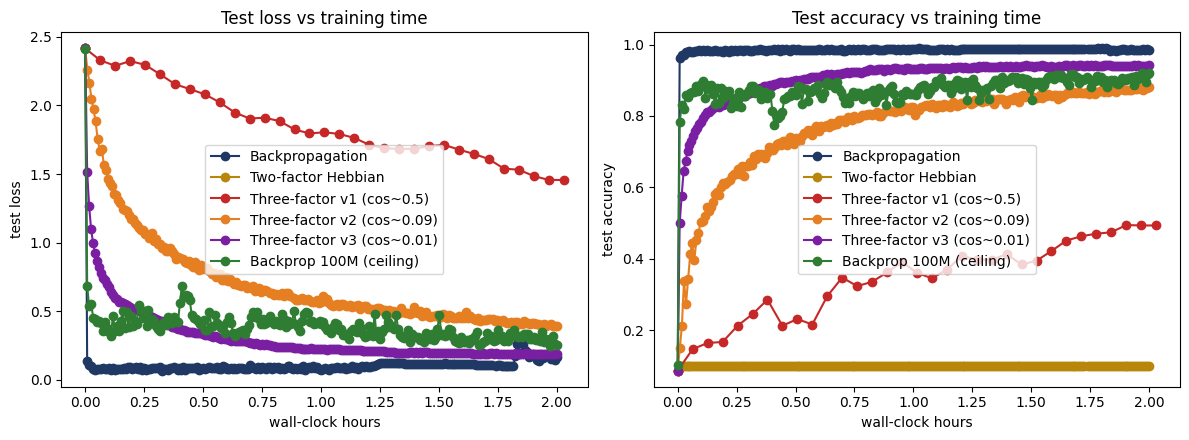

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for m in R:
    c = R[m]['curve']; hrs = [t/3600 for t in c['t_sec']]
    ax[0].plot(hrs, c['test_loss'], 'o-', color=COLORS[m], label=LABELS[m])
    ax[1].plot(hrs, c['test_acc'],  'o-', color=COLORS[m], label=LABELS[m])
ax[0].set_xlabel('wall-clock hours'); ax[0].set_ylabel('test loss'); ax[0].set_title('Test loss vs training time'); ax[0].legend()
ax[1].set_xlabel('wall-clock hours'); ax[1].set_ylabel('test accuracy'); ax[1].set_title('Test accuracy vs training time'); ax[1].legend()
plt.tight_layout(); plt.show()

## 5. Compare Predictions

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.02MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.4MB/s]


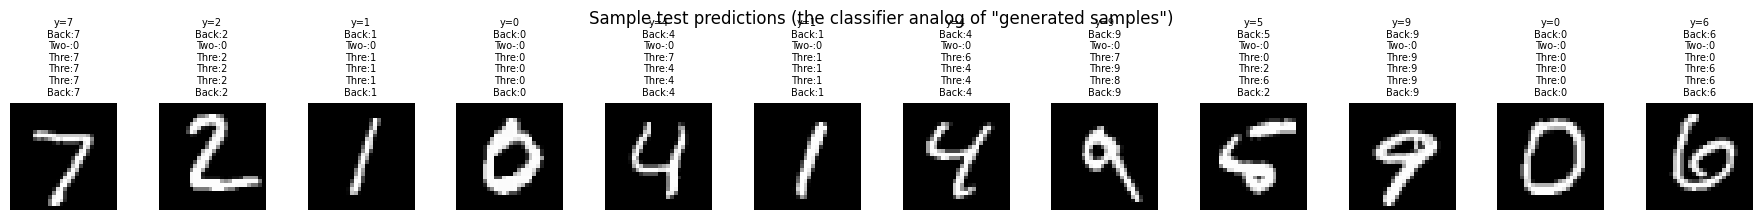

In [6]:
import math, torch
import torch.nn as nn
import torch.nn.functional as F

class MHSA(nn.Module):
    def __init__(self, dim, heads):
        super().__init__()
        assert dim % heads == 0, "EMBED_DIM must be divisible by HEADS"
        self.h, self.dh = heads, dim // heads
        self.scale = self.dh ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.h, self.dh).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        att = (q @ k.transpose(-2, -1)) * self.scale
        att = att.softmax(dim=-1)
        o = (att @ v).transpose(1, 2).reshape(B, N, D)
        return self.proj(o)

class Block(nn.Module):
    def __init__(self, dim, heads, mlp_ratio):
        super().__init__()
        self.n1 = nn.LayerNorm(dim); self.attn = MHSA(dim, heads)
        self.n2 = nn.LayerNorm(dim)
        h = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(dim, h), nn.GELU(), nn.Linear(h, dim))
    def forward(self, x):
        x = x + self.attn(self.n1(x))
        x = x + self.mlp(self.n2(x))
        return x

class ViT(nn.Module):
    def __init__(self, img=28, patch=7, in_ch=1, dim=176, depth=4, heads=8,
                 mlp_ratio=2, num_classes=10):
        super().__init__()
        assert img % patch == 0
        self.n = (img // patch) ** 2
        self.patch = nn.Conv2d(in_ch, dim, kernel_size=patch, stride=patch)
        self.cls = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos = nn.Parameter(torch.zeros(1, self.n + 1, dim))
        nn.init.trunc_normal_(self.pos, std=0.02)
        nn.init.trunc_normal_(self.cls, std=0.02)
        self.blocks = nn.ModuleList([Block(dim, heads, mlp_ratio) for _ in range(depth)])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, num_classes)
    def forward(self, x):
        B = x.shape[0]
        x = self.patch(x).flatten(2).transpose(1, 2)      # (B, n, dim)
        cls = self.cls.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)[:, 0]
        return self.head(x)

import torchvision
_t = torchvision.datasets.MNIST('./data', train=False, download=True)
Xte = ((_t.data.float()/255-0.1307)/0.3081).unsqueeze(1).to(device); Yte = _t.targets.to(device)

def load_model(m):
    cfg = R[m]['meta']['config']
    net = ViT(28, cfg['PATCH'], 1, cfg['EMBED_DIM'], cfg['DEPTH'], cfg['HEADS'], cfg['MLP_RATIO'], 10).to(device)
    _cp = next((os.path.join(d, f'{m}.pt') for d in [CKPT_DIR] + EXTRA_CKPT_DIRS
                if os.path.exists(os.path.join(d, f'{m}.pt'))), os.path.join(CKPT_DIR, f'{m}.pt'))
    ck = torch.load(_cp, map_location=device)['method']
    net.load_state_dict(ck['net'] if 'net' in ck else ck['params'])
    net.eval(); return net

N = 12; idx = torch.arange(N)
preds = {}
for m in R:
    with torch.no_grad(): preds[m] = load_model(m)(Xte[idx]).argmax(-1).cpu()
fig, axes = plt.subplots(1, N, figsize=(1.5*N, 2.2))
for j in range(N):
    axes[j].imshow(Xte[idx[j],0].cpu(), cmap='gray'); axes[j].axis('off')
    axes[j].set_title('y=%d\n' % Yte[idx[j]].item() +
                      '\n'.join('%s:%d' % (LABELS[m][:4], preds[m][j].item()) for m in R), fontsize=7)
plt.suptitle('Sample test predictions (the classifier analog of "generated samples")'); plt.tight_layout(); plt.show()

## 6. Compare Cost & Memory

In [7]:
def fwd_equiv(m):
    st = R[m]['meta']['total_steps']
    if m == 'three_factor': return st * 2 * R[m]['meta']['config'].get('M', 0)   # antithetic probes
    if m.startswith('backprop'):     return st * 3                                        # fwd + ~2x bwd
    return st * 2                                                                # two-factor: acts + measured loss
print(f'{"method":26}{"steps":>10}{"fwd-pass-equiv":>16}{"wall h":>9}{"peak MB":>10}')
print('-'*71)
for m in R:
    md = R[m]['meta']
    print(f'{LABELS[m]:26}{md["total_steps"]:>10,}{fwd_equiv(m):>16,}{md["wall_clock_sec"]/3600:>9.2f}'
          f'{md.get("peak_mem_mb", float("nan")):>10.1f}')

method                         steps  fwd-pass-equiv   wall h   peak MB
-----------------------------------------------------------------------
Backpropagation              692,954       2,078,862     2.00     465.3
Two-factor Hebbian           874,811       1,749,622     2.00    1540.1
Three-factor v1 (cos~0.5)         33      22,287,474     2.03   16969.8
Three-factor v2 (cos~0.09)     1,367           2,734     2.00   16179.6
Three-factor v3 (cos~0.01)    87,664         175,328     2.00    2160.9
Backprop 100M (ceiling)      115,417         346,251     2.00    2776.6


## Peak training memory — backprop vs. forward-only (no activation tape)

Measures the **activation tape** backprop must retain for its backward pass — memory the forward-only three-factor rule never allocates (it only *evaluates* the loss). Self-contained and unexecuted: run it to print the numbers next to the accuracy results. Exact (`torch.autograd.graph.saved_tensors_hooks`), at this section's training batch size.

In [ ]:
# ============================================================================
# Peak training memory: backprop vs the forward-only three-factor rule.
# Backprop must retain an "activation tape" (one saved tensor per layer op) so
# the backward pass can run; the forward-only rule only EVALUATES the loss, so
# it stores none of it -> training memory stays at the inference footprint.
# Measured exactly via autograd's own saved-tensor hooks (not an estimate).
# Also writes peak_training_memory.csv into the exports/ folder so it rides
# along in the results zip next to summary.csv. Self-contained + unexecuted.
# ============================================================================
import torch, torch.nn as nn, torch.nn.functional as F
_MEM_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

def _activation_tape_bytes(model, xshape, lossfn, make_target):
    model = model.to(_MEM_DEVICE)
    _pp = {p.untyped_storage().data_ptr() for p in model.parameters()}
    _seen, _isp = {}, {}
    def _pack(t):
        st = t.untyped_storage(); dp = st.data_ptr()
        _seen[dp] = st.nbytes(); _isp[dp] = (dp in _pp); return t
    def _unpack(t): return t
    x = torch.randn(*xshape, device=_MEM_DEVICE)
    with torch.autograd.graph.saved_tensors_hooks(_pack, _unpack):
        out = model(x); loss = lossfn(out, make_target(out)); loss.backward()
    return sum(nb for dp, nb in _seen.items() if not _isp[dp])  # activations only (params excluded)

def _report_training_memory(label, model, xshape, lossfn, make_target):
    P = sum(p.numel() for p in model.parameters()); pmem = P*4
    tape = _activation_tape_bytes(model, xshape, lossfn, make_target)
    common = 4*pmem; bp, loc = common + tape, common; MB = 1e6
    print("="*78)
    print(f"PEAK TRAINING MEMORY  |  {label}")
    print(f"  params P = {P:,}  ({pmem/MB:.2f} MB weights)   |   batch = {xshape[0]}   |   device = {_MEM_DEVICE}")
    print("-"*78)
    print(f"  activation tape backprop must retain : {tape/MB:8.2f} MB   ({tape/max(pmem,1):.1f}x the weights)")
    print(f"  forward-only three-factor rule       : {0.0:8.2f} MB   (no tape -- structural)")
    print(f"  est. training memory (same Adam both = 4P shared):")
    print(f"      backprop     : {bp/MB:8.2f} MB")
    print(f"      forward-only : {loc/MB:8.2f} MB   ->  backprop needs {bp/max(loc,1):.2f}x the memory")
    print(f"  (tape ~ linear in batch; measured via torch.autograd saved_tensors_hooks)")
    print("="*78)
    return {"section": label, "arch": type(model).__name__.replace("_Mem",""),
            "params": P, "batch": xshape[0], "weights_MB": round(pmem/MB, 2),
            "activation_tape_MB": round(tape/MB, 2), "tape_over_weights": round(tape/max(pmem,1), 2),
            "backprop_train_MB": round(bp/MB, 2), "forward_only_train_MB": round(loc/MB, 2),
            "backprop_over_forward_only": round(bp/max(loc,1), 2)}

class _MemMHSA(nn.Module):
    def __init__(self,dim,heads):
        super().__init__(); self.h,self.dh=heads,dim//heads; self.scale=self.dh**-0.5
        self.qkv=nn.Linear(dim,dim*3); self.proj=nn.Linear(dim,dim)
    def forward(self,x):
        B,N,D=x.shape; qkv=self.qkv(x).reshape(B,N,3,self.h,self.dh).permute(2,0,3,1,4)
        q,k,v=qkv[0],qkv[1],qkv[2]; att=((q@k.transpose(-2,-1))*self.scale).softmax(-1)
        return self.proj((att@v).transpose(1,2).reshape(B,N,D))
class _MemBlock(nn.Module):
    def __init__(self,dim,heads,mlp_ratio):
        super().__init__(); self.n1=nn.LayerNorm(dim); self.attn=_MemMHSA(dim,heads)
        self.n2=nn.LayerNorm(dim); h=int(dim*mlp_ratio)
        self.mlp=nn.Sequential(nn.Linear(dim,h),nn.GELU(),nn.Linear(h,dim))
    def forward(self,x): x=x+self.attn(self.n1(x)); return x+self.mlp(self.n2(x))
class _MemViT(nn.Module):
    def __init__(self,img,patch,in_ch,dim,depth,heads,mlp_ratio,num_classes):
        super().__init__(); self.n=(img//patch)**2
        self.patch=nn.Conv2d(in_ch,dim,patch,patch); self.cls=nn.Parameter(torch.zeros(1,1,dim))
        self.pos=nn.Parameter(torch.zeros(1,self.n+1,dim))
        self.blocks=nn.ModuleList([_MemBlock(dim,heads,mlp_ratio) for _ in range(depth)])
        self.norm=nn.LayerNorm(dim); self.head=nn.Linear(dim,num_classes)
    def forward(self,x):
        B=x.shape[0]; x=self.patch(x).flatten(2).transpose(1,2); cls=self.cls.expand(B,-1,-1)
        x=torch.cat([cls,x],1)+self.pos
        for blk in self.blocks: x=blk(x)
        return self.head(self.norm(x)[:,0])

_MEM_ROW = _report_training_memory("S8 ViT classifier (MNIST)", _MemViT(28,7,1,176,4,8,2,10), (64,1,28,28), lambda o,t: F.cross_entropy(o,t), lambda o: torch.randint(0,10,(o.shape[0],),device=o.device))

# --- stash + persist so the export cell's zip picks it up (rides next to summary.csv) ---
PEAK_MEM_ROWS = [_MEM_ROW]
try:
    import os as _os, csv as _csv
    if 'STORE' in globals():
        _ed = _os.path.join(STORE, 'exports'); _os.makedirs(_ed, exist_ok=True)
        with open(_os.path.join(_ed, 'peak_training_memory.csv'), 'w', newline='') as _f:
            _w = _csv.DictWriter(_f, fieldnames=list(PEAK_MEM_ROWS[0].keys())); _w.writeheader()
            for _r in PEAK_MEM_ROWS: _w.writerow(_r)
        print('  saved ->', _os.path.join(_ed, 'peak_training_memory.csv'))
    else:
        print('  (STORE not defined yet -- CSV will be written by the export cell / re-run after Setup)')
except Exception as _e:
    print('  (peak_training_memory.csv not written:', _e, ')')


## 7. Head-to-head — three-factor v1 vs v2

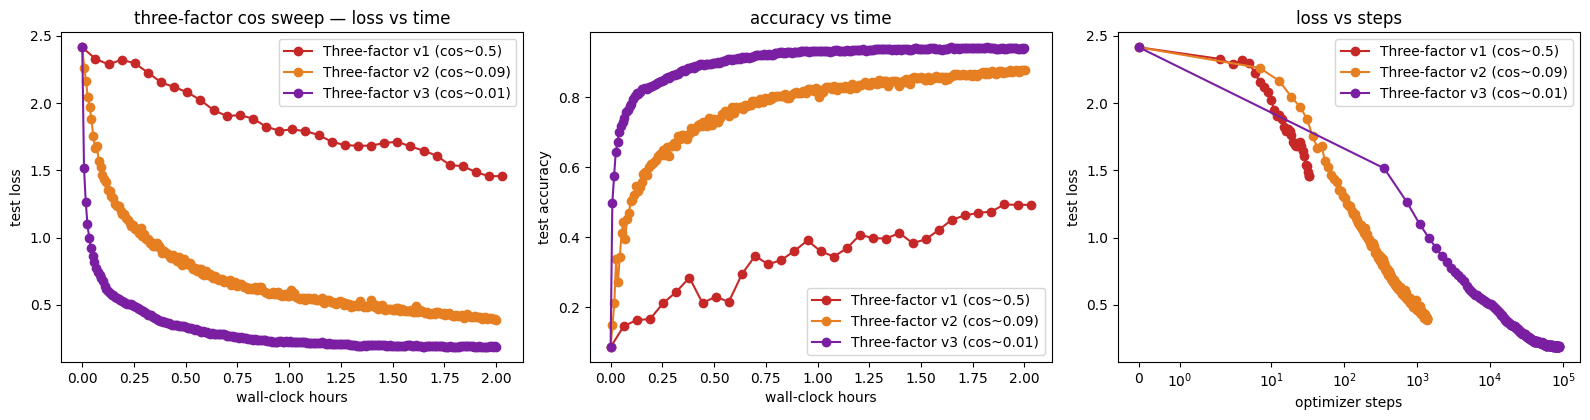

variant                                M    cos~     steps   best_loss  final_acc
---------------------------------------------------------------------------------
Three-factor v1 (cos~0.5)        337,689   0.500        33      1.4567      0.493
Three-factor v2 (cos~0.09)         8,192   0.090     1,367      0.3905      0.880
Three-factor v3 (cos~0.01)           101   0.010    87,664      0.1856      0.941

Lowest best test loss in the same wall-clock budget: Three-factor v3 (cos~0.01) (0.1856). Reading down the cos column shows whether pushing cos lower (fewer probes, more steps) keeps helping or finally breaks down.


In [8]:
# Head-to-head across the three-factor cos sweep: does MORE-but-noisier keep winning in equal wall-clock?
tf = [m for m in ['three_factor', 'three_factor_v2', 'three_factor_v3'] if m in R]
if len(tf) >= 2:
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
    for m in tf:
        c = R[m]['curve']; hrs = [t/3600 for t in c['t_sec']]
        ax[0].plot(hrs, c['test_loss'], 'o-', color=COLORS[m], label=LABELS[m])
        ax[1].plot(hrs, c['test_acc'],  'o-', color=COLORS[m], label=LABELS[m])
        ax[2].plot(c['step'], c['test_loss'], 'o-', color=COLORS[m], label=LABELS[m])
    ax[0].set_xlabel('wall-clock hours'); ax[0].set_ylabel('test loss'); ax[0].set_title('three-factor cos sweep — loss vs time'); ax[0].legend()
    ax[1].set_xlabel('wall-clock hours'); ax[1].set_ylabel('test accuracy'); ax[1].set_title('accuracy vs time'); ax[1].legend()
    ax[2].set_xlabel('optimizer steps'); ax[2].set_ylabel('test loss'); ax[2].set_title('loss vs steps'); ax[2].set_xscale('symlog'); ax[2].legend()
    plt.tight_layout(); plt.show()

    print(f'{"variant":30}{"M":>10}{"cos~":>8}{"steps":>10}{"best_loss":>12}{"final_acc":>11}')
    print('-'*81)
    for m in tf:
        md, s = R[m]['meta'], R[m]['summary']
        M = md['config'].get('M') or 0; P = md['P']
        cos = (M/(M+P+1))**0.5 if M else float('nan')
        print(f'{LABELS[m]:30}{M:>10,}{cos:>8.3f}{md["total_steps"]:>10,}{s["best_loss"]:>12.4f}{s["final_acc"]:>11.3f}')
    best = min(tf, key=lambda m: R[m]['summary']['best_loss'])
    print(f'\nLowest best test loss in the same wall-clock budget: {LABELS[best]} '
          f'({R[best]["summary"]["best_loss"]:.4f}). Reading down the cos column shows whether pushing cos '
          f'lower (fewer probes, more steps) keeps helping or finally breaks down.')
else:
    print('Head-to-head needs >=2 three-factor variants present (run at least two of 03 / 05 / 06).')

## 8. Summary table (all methods)

In [9]:
print(f'{"Experiment":26}{"Epochs":>9}{"First loss":>12}{"Final loss":>12}{"Best loss":>11}{"Reduc %":>9}{"Test acc":>10}')
print('-'*89)
for m in R:
    md, s = R[m]['meta'], R[m]['summary']
    print(f'{LABELS[m]:26}{md["epochs"]:>9.3f}{s["initial_loss"]:>12.4f}{s["final_loss"]:>12.4f}'
          f'{s["best_loss"]:>11.4f}{s["reduction_pct"]:>9.1f}{s["final_acc"]:>10.3f}')
print('\n("Epochs" is fractional: in equal wall-clock, backprop runs many epochs while the three-factor '
      'rule runs a fraction of one -- that gap is the from-scratch barrier.)')

Experiment                   Epochs  First loss  Final loss  Best loss  Reduc %  Test acc
-----------------------------------------------------------------------------------------
Backpropagation             739.151      2.4146      0.1657     0.0679     97.2     0.986
Two-factor Hebbian          933.132      2.4146         nan     2.4146      0.0     0.098
Three-factor v1 (cos~0.5)     0.035      2.4146      1.4567     1.4567     39.7     0.493
Three-factor v2 (cos~0.09)    1.458      2.4146      0.3905     0.3905     83.8     0.880
Three-factor v3 (cos~0.01)   93.508      2.4146      0.1888     0.1856     92.3     0.941
Backprop 100M (ceiling)     123.111      2.4084      0.2548     0.2441     89.9     0.919

("Epochs" is fractional: in equal wall-clock, backprop runs many epochs while the three-factor rule runs a fraction of one -- that gap is the from-scratch barrier.)


In [10]:
# ── Export §8 comparison: figures (PNG) + data (CSV) → a Drive folder, then download a zip ──
import os, csv, glob, shutil
import matplotlib.pyplot as plt

EXPORT_DIR = os.path.join(STORE, 'exports'); os.makedirs(EXPORT_DIR, exist_ok=True)

# 1) CSVs — long-format curves + one summary row per method
with open(os.path.join(EXPORT_DIR, 'curves.csv'), 'w', newline='') as f:
    w = csv.writer(f); w.writerow(['method', 't_sec', 'step', 'epoch', 'train_loss', 'test_loss', 'test_acc'])
    for m in R:
        c = R[m]['curve']
        for i in range(len(c['t_sec'])):
            w.writerow([m, c['t_sec'][i], c['step'][i], c['epoch'][i], c['train_loss'][i], c['test_loss'][i], c['test_acc'][i]])

with open(os.path.join(EXPORT_DIR, 'summary.csv'), 'w', newline='') as f:
    w = csv.writer(f); w.writerow(['method','P','total_steps','wall_clock_h','M','cos',
                                   'initial_loss','final_loss','best_loss','reduction_pct','final_acc','best_acc','peak_mem_mb'])
    for m in R:
        md, s = R[m]['meta'], R[m]['summary']; M = md['config'].get('M') or 0
        cos = (M/(M+md['P']+1))**0.5 if M else ''
        w.writerow([m, md['P'], md['total_steps'], round(md['wall_clock_sec']/3600, 3), M, cos,
                    s['initial_loss'], s['final_loss'], s['best_loss'], round(s['reduction_pct'], 2),
                    s['final_acc'], s['best_acc'], md.get('peak_mem_mb', '')])

# 2) Figures — redraw the comparison plots and save PNGs; copy any per-run *_progress.png
def _save(fig, name): fig.savefig(os.path.join(EXPORT_DIR, name), dpi=120, bbox_inches='tight'); plt.close(fig)
if R:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
    for m in R:
        c = R[m]['curve']; hrs = [t/3600 for t in c['t_sec']]
        ax[0].plot(hrs, c['test_loss'], 'o-', color=COLORS[m], label=LABELS[m])
        ax[1].plot(hrs, c['test_acc'],  'o-', color=COLORS[m], label=LABELS[m])
    ax[0].set_xlabel('hours'); ax[0].set_ylabel('test loss'); ax[0].set_title('Test loss vs time'); ax[0].legend()
    ax[1].set_xlabel('hours'); ax[1].set_ylabel('test accuracy'); ax[1].set_title('Test accuracy vs time'); ax[1].legend()
    _save(fig, 'curves_all_methods.png')
    tf = [m for m in ['three_factor', 'three_factor_v2', 'three_factor_v3'] if m in R]
    if len(tf) >= 2:
        fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))
        for m in tf:
            c = R[m]['curve']; hrs = [t/3600 for t in c['t_sec']]
            ax[0].plot(hrs, c['test_loss'], 'o-', color=COLORS[m], label=LABELS[m])
            ax[1].plot(c['step'], c['test_loss'], 'o-', color=COLORS[m], label=LABELS[m])
        ax[0].set_xlabel('hours'); ax[0].set_title('cos sweep: loss vs time'); ax[0].legend()
        ax[1].set_xscale('symlog'); ax[1].set_xlabel('steps'); ax[1].set_title('cos sweep: loss vs steps'); ax[1].legend()
        _save(fig, 'cos_sweep.png')
for p in glob.glob(os.path.join(STORE, 'figures', '*_progress.png')):
    try: shutil.copy(p, EXPORT_DIR)
    except Exception: pass
print('exported to', EXPORT_DIR, '->', sorted(os.listdir(EXPORT_DIR)))

# 3) zip + browser download (the folder already lives on Drive)
_ztarget = '/content' if os.path.isdir('/content') else os.path.dirname(EXPORT_DIR)
_zip = shutil.make_archive(os.path.join(_ztarget, f'{DRIVE_SUBDIR}_exports'), 'zip', EXPORT_DIR)
try:
    from google.colab import files; files.download(_zip)
except Exception as e:
    print('download skipped:', e, '- zip at', _zip)

exported to /content/drive/MyDrive/Section8_regime1/exports -> ['backprop_100M_progress.png', 'backprop_progress.png', 'cos_sweep.png', 'curves.csv', 'curves_all_methods.png', 'summary.csv', 'three_factor_progress.png', 'three_factor_v2_progress.png', 'three_factor_v3_progress.png', 'two_factor_progress.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>